In [4]:
import pandas as pd

filename = "../../data/processed/frogID5_database_prepared.csv"
frogID5_database_final = pd.read_csv(filename, sep=',', on_bad_lines='skip')

In [5]:
### preparing data

monthly_frogs_by_state = frogID5_database_final.groupby(['month', 'stateProvince']).size().reset_index(name='counts')
pivot_table = monthly_frogs_by_state.pivot(index='month', columns='stateProvince', values='counts')

## excluding the stateProvinces that have under 50000 recordings in total
stateProvince_counts = frogID5_database_final.groupby('stateProvince').size().reset_index(name='counts')
stateProvinces_list_to_exclude = stateProvince_counts[stateProvince_counts['counts'] < 50000]['stateProvince'].tolist()
filtered_frogs_by_state = pivot_table.drop(columns=stateProvinces_list_to_exclude)

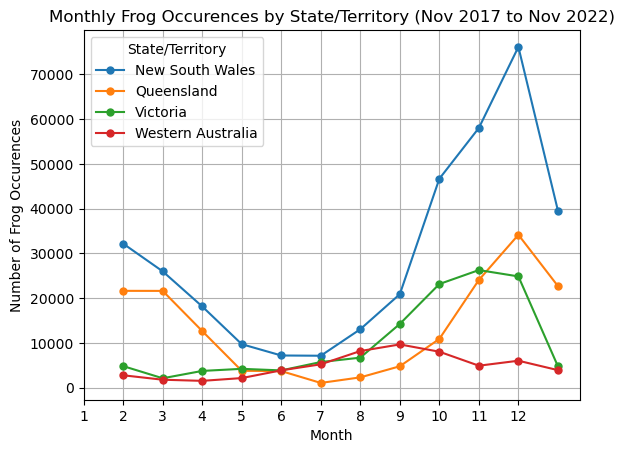

In [6]:
import matplotlib.pyplot as plt

# plotting
monthly_counts_by_state_territory_plot = filtered_frogs_by_state.plot(marker='o', markersize=5)

monthly_counts_by_state_territory_plot.set_title('Monthly Frog Occurences by State/Territory (Nov 2017 to Nov 2022)')
monthly_counts_by_state_territory_plot.set_xlabel('Month')
monthly_counts_by_state_territory_plot.set_ylabel('Number of Frog Occurences')

monthly_counts_by_state_territory_plot.legend(title='State/Territory')
monthly_counts_by_state_territory_plot.grid(True)

# adding more horizontal stripes and adding even numbers to x-axis
months = filtered_frogs_by_state.index.astype(int)
monthly_counts_by_state_territory_plot.set_xticks(range(12))
monthly_counts_by_state_territory_plot.set_xticklabels(months)

plt.show()